In [9]:
import numpy as np
import pandas as pd
from imdb.utils.config import load_config

cfg = load_config("../configs/paths.yaml")

df = pd.read_parquet("../"+cfg["data"]["processed"])

In [10]:
df.head()

,review_standardized,sentiment,qm_density,em_density,uppercase_count,vader_compound,word_count,TTR,review_lemmatized
0,one of the other reviewers has mentioned that ...,1,0.000000,0.000000,3,-0.9916,313,0.600639,one reviewer mentioned watching oz episode hoo...
1,a wonderful little production the filming tech...,1,0.000000,0.006250,0,0.9670,160,0.675000,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,1,0.005988,0.000000,0,0.9519,167,0.700599,thought wonderful way spend time hot summer we...
3,basically there s a family where a little boy ...,0,0.000000,0.015038,2,-0.9213,133,0.631579,basically family little boy jake think zombie ...
4,petter mattei s love in the time of money is a...,1,0.000000,0.000000,0,0.9744,228,0.614035,petter mattei love time money visually stunnin...


In [11]:
df[[
    'qm_density', 
    'em_density', 
    'uppercase_count', 
    'vader_compound', 
    'word_count', 
    'TTR'
    ]].values

array([[ 0.00000000e+00,  0.00000000e+00,  3.00000000e+00,
        -9.91600000e-01,  3.13000000e+02,  6.00638978e-01],
       [ 0.00000000e+00,  6.25000000e-03,  0.00000000e+00,
         9.67000000e-01,  1.60000000e+02,  6.75000000e-01],
       [ 5.98802395e-03,  0.00000000e+00,  0.00000000e+00,
         9.51900000e-01,  1.67000000e+02,  7.00598802e-01],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -9.73400000e-01,  2.36000000e+02,  5.88983051e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -8.65700000e-01,  2.16000000e+02,  6.99074074e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         6.97500000e-01,  1.27000000e+02,  6.92913386e-01]],
      shape=(50000, 6))

--- VADER PERFORMANCE SUMMARY ---
Simple Polarity Accuracy: 69.51%
Number of 'Neutral' (0.0) reviews: 28
Neutral reviews Ground Truth: 42.86% are actually positive

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.79      0.53      0.63     25000
           1       0.65      0.86      0.74     25000

    accuracy                           0.70     50000
   macro avg       0.72      0.70      0.69     50000
weighted avg       0.72      0.70      0.69     50000

ROC AUC Score: 0.7843


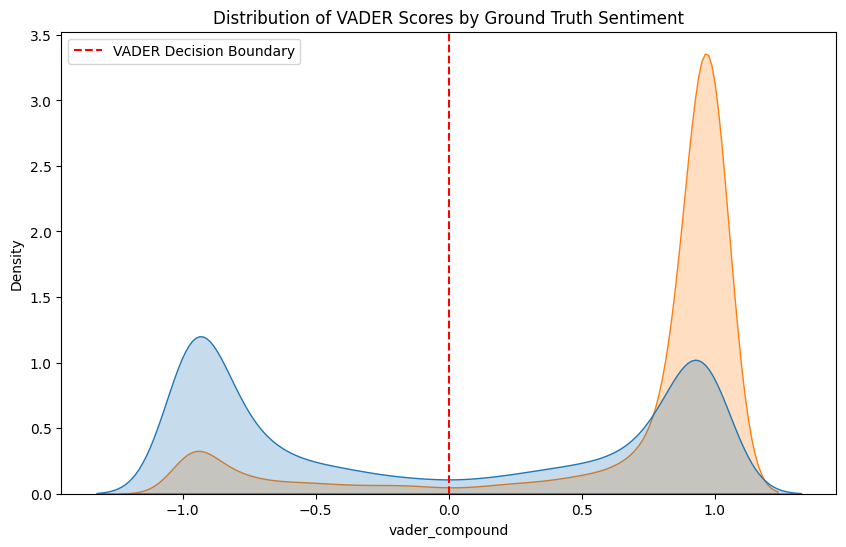

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Create a binary prediction based on VADER
# We use >= 0 as positive, < 0 as negative
df['vader_pred'] = np.where(df['vader_compound'] >= 0, 1, 0)

# 2. Basic Polarity Agreement
print("--- VADER PERFORMANCE SUMMARY ---")
accuracy = (df['vader_pred'] == df['sentiment']).mean()
print(f"Simple Polarity Accuracy: {accuracy:.2%}")

# 3. Check 'Neutral' reviews (VADER score of exactly 0)
neutrals = df[df['vader_compound'] == 0]
print(f"Number of 'Neutral' (0.0) reviews: {len(neutrals)}")
if len(neutrals) > 0:
    print(f"Neutral reviews Ground Truth: {neutrals['sentiment'].mean():.2%} are actually positive")

# 4. Detailed Metrics
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(df['sentiment'], df['vader_pred']))

# 5. ROC AUC - This measures how well VADER separates the two classes
auc = roc_auc_score(df['sentiment'], df['vader_compound'])
print(f"ROC AUC Score: {auc:.4f}")

# 6. VISUALIZATION: The Distribution Overlap
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='vader_compound', hue='sentiment', fill=True, common_norm=False)
plt.title('Distribution of VADER Scores by Ground Truth Sentiment')
plt.axvline(0, color='red', linestyle='--', label='VADER Decision Boundary')
plt.legend()
plt.show()

/home/nurlan/projects/imdb_reviews/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer and calculating exact token lengths (this takes a few seconds)...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (553 > 512). Running this sequence through the model will result in indexing errors


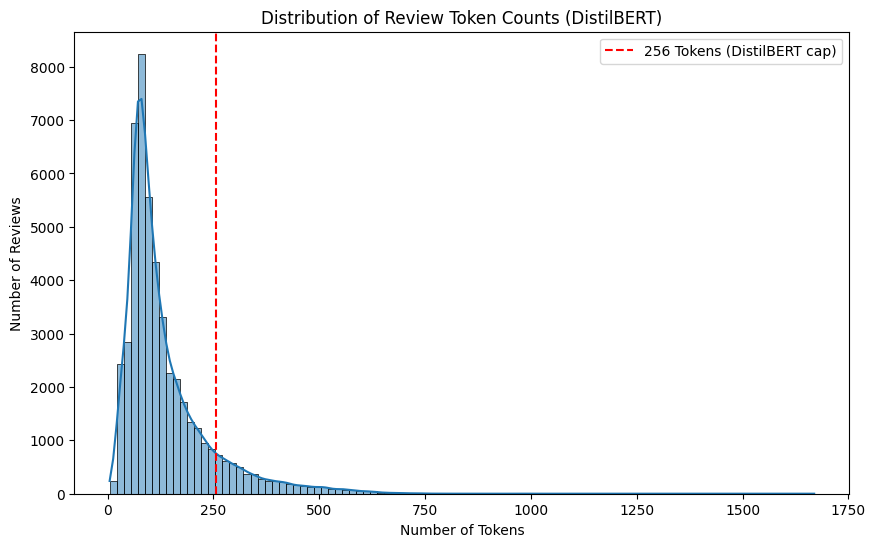

Reviews fully captured (<= 256 tokens): 44495 out of 50000 (89.0%)


In [ ]:
from transformers import AutoTokenizer
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading tokenizer and calculating exact token lengths (this takes a few seconds)...")
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
# Tokenize without truncation to get the true length of every review
tokens = tokenizer(df['review_lemmatized'].astype(str).tolist(), add_special_tokens=True, truncation=False)
df['token_count'] = [len(t) for t in tokens['input_ids']]

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='token_count', bins=100, kde=True)
plt.axvline(256, color='red', linestyle='--', label='256 Tokens (DistilBERT cap)')
plt.title('Distribution of Review Token Counts (DistilBERT)')
plt.xlabel('Number of Tokens')
plt.ylabel('Number of Reviews')
plt.legend()
plt.show()

less_than_256 = (df['token_count'] <= 256).sum()
print(f"Reviews fully captured (<= 256 tokens): {less_than_256} out of {len(df)} ({less_than_256/len(df):.1%})")
